# Benchmarks

## Initialize

In [1]:
#library(Rmisc)
library(dtplyr)
library(tidyverse)
library(glue)
library(arrow)
library(patchwork)
library(data.table)
library("jsonlite")
library(ggthemes)

Warning message:
“package ‘dtplyr’ was built under R version 4.0.5”
Warning message:
“package ‘tidyverse’ was built under R version 4.0.5”
── Attaching packages ─────────────────────────────────────── tidyverse 1.3.2 ──
✔ ggplot2 3.3.6      ✔ purrr   0.3.5 
✔ tibble  3.1.8      ✔ dplyr   1.0.10
✔ tidyr   1.2.1      ✔ stringr 1.5.0 
✔ readr   2.1.2      ✔ forcats 0.5.2 
Warning message:
“package ‘ggplot2’ was built under R version 4.0.5”
Warning message:
“package ‘tibble’ was built under R version 4.0.5”
Warning message:
“package ‘tidyr’ was built under R version 4.0.5”
Warning message:
“package ‘readr’ was built under R version 4.0.5”
Warning message:
“package ‘dplyr’ was built under R version 4.0.5”
Warning message:
“package ‘forcats’ was built under R version 4.0.5”
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
Warning message:
“package ‘glue’ was built under R version 4.0.

In [2]:
if (grepl("sc", Sys.info()[["nodename"]], fixed=TRUE)) {
    base_path = "/sc-projects/sc-proj-ukb-cvd"
} else {
    base_path = "/data/analysis/ag-reils/ag-reils-shared/cardioRS"}
print(base_path)

project_label="22_medical_records"
project_path = glue("{base_path}/results/projects/{project_label}")
figure_path = glue("{project_path}/figures")
output_path = glue("{project_path}/data")

experiment = 230425
experiment_path = glue("{output_path}/{experiment}")

[1] "/sc-projects/sc-proj-ukb-cvd"


In [3]:
base_size = 8
title_size = 10
facet_size = 9
geom_text_size=3
theme_set(theme_classic(base_size = base_size) + 
          theme(strip.background = element_blank(), plot.title=element_text(size=title_size, hjust=0), 
                strip.text.x = element_text(size = facet_size),axis.title=element_text(size=10), axis.text=element_text(size=8, color="black"),
                legend.position="bottom", axis.line = element_line(size = 0.2), axis.ticks=element_line(size=0.2), panel.grid.major.y=element_line()))

In [4]:
colors_dict = read_json("colors.json")
color_map <- c(
    "Identity(AgeSex)+MLP" = colors_dict$pastel$red$mid,
    "Identity(Records)+MLP" = colors_dict$pastel$red$mid,
    "GNN(Records)+MLP" = colors_dict$pastel$red$mid,
    "Identity(AgeSex+Records)+MLP" = colors_dict$pastel$red$mid,
    "GNN(AgeSex+Records)+MLP" = colors_dict$pastel$red$mid
)

In [5]:
endpoint_defs = arrow::read_feather(glue("{output_path}/phecode_defs_220306.feather")) %>% arrange(endpoint)
endpoints_md = fread(glue("{experiment_path}/endpoints.csv"), colClasses=c("phecode"="character"))
endpoints = sort(endpoints_md$endpoint)

In [6]:
endpoint_map = endpoint_defs$phecode_string
names(endpoint_map) =  endpoint_defs$endpoint
endpoint_order = (endpoint_defs %>% arrange(as.numeric(phecode)))$endpoint

In [7]:
endpoint_selection = c(
    
   'phecode_401', #  "Hypertension", # intervention
    'phecode_202', #  "Diabetes mellitus", # intervention
    'phecode_416-21', #  "Atrial fibrillation", # intervention
    'phecode_468', #  "Pneumonia", # intervention
    'phecode_474', #  "Chronic obstructive pulmonary disease [COPD]", # interventio
    'phecode_583', #  "Chronic kidney disease", # intervention
    
    'phecode_404', #  "Ischemic heart disease",
    'phecode_404-1', #  "Myocardial infarction [Heart attack]", # intervention
    'phecode_431-11', #  "Cerebral infarction [Ischemic stroke]",
    'phecode_424', #  "Heart failure", # intervention
    'phecode_420', #  "Cardiac arrest", # intervention
    'OMOP_4306655', #  "All-Cause Death", # intervention
    
    'phecode_438-11',   #  "Abdominal aortic aneurysm",
    'phecode_440-3',#  "Pulmonary embolism", # intervention
    'phecode_413-21',#  "Aortic stenosis", # intervention
    'phecode_413-11', #  "Mitral valve insufficiency",
    'phecode_410-2',#  "Endocarditis",
    'phecode_400',#  "Rheumatic fever and chronic rheumatic heart diseases",	
    
    'phecode_164', #  "Anemia", # intervention
    'phecode_718',  #  "Back pain", # intervention
    'phecode_324-11', #  "Parkinson's disease (Primary)",
    'phecode_705-1', #  "Rheumatoid arthritis", # NEW + interventio
    'phecode_665', #  "Psoriasis", # interesting
    'phecode_284'#  "Suicide ideation and attempt or self harm" # intervention
)
endpoint_defs = endpoint_defs %>% 
    mutate(name = phecode_string) %>%
    mutate(name = 
           case_when( 
               phecode_string == "Myocardial infarction [Heart attack]"~"Myocardial infarction",
               phecode_string == "Cerebral infarction [Ischemic stroke]"~"Ischemic stroke",
               phecode_string == "Chronic obstructive pulmonary disease [COPD]"~"COPD",
               phecode_string == "Mitral valve insufficiency"~"Mitral insufficiency",
               phecode_string == "Parkinson's disease (Primary)"~"Parkinson's",
               phecode_string == "Suicide ideation and attempt or self harm"~"Suicide attempt",
               phecode_string == "Ischemic heart disease"~"Ischemic HD",
               phecode_string == "Chronic kidney disease"~"Chronic KD",
               phecode_string == "Rheumatic fever and chronic rheumatic heart diseases"~"Rheumatic HD",
               phecode_string == "Abdominal aortic aneurysm"~"Abdominal AA",
                  TRUE ~ name)
           )
            
endpoint_map = endpoint_defs$name
names(endpoint_map) =  endpoint_defs$endpoint
#endpoint_order = (endpoint_defs %>% arrange(as.numeric(phecode)))$endpoint
endpoint_order = endpoint_selection

## Load data

# Load Benchmarks

In [8]:
name = "benchmarks_cindex_230425"
benchmark_endpoints = arrow::read_feather(glue("{experiment_path}/{name}.feather")) %>% left_join(endpoints_md) 

Joining, by = "endpoint"


In [9]:
benchmark_endpoints %>% group_by(endpoint, score)  %>% summarise(cindex=mean(cindex)) %>% group_by(score) %>% summarise(mean(cindex)) %>% arrange(`mean(cindex)`)

`summarise()` has grouped output by 'endpoint'. You can override using the
`.groups` argument.


score,mean(cindex)
<chr>,<dbl>
Comorbidities,0.5014333
Age+Sex,0.5980494
Age+Sex+Comorbidities,0.6218427
SCORE2,0.6246469
ASCVD,0.6323539
MedicalHistoryLM,0.6401681
Age+Sex+Comorbidities+MedicalHistoryLM,0.6431330
Age+Sex+MedicalHistoryLM,0.6481154
QRISK3,0.6529786


In [10]:
endpoints_sorted = (benchmark_endpoints %>% 
    filter(score == "Age+Sex+MedicalHistory") %>% 
    group_by(endpoint, score) %>% 
    summarise(cindex=mean(cindex, na.rm=TRUE)) %>% 
    arrange(cindex) %>% ungroup())$endpoint

`summarise()` has grouped output by 'endpoint'. You can override using the
`.groups` argument.


In [11]:
categories_sorted = (endpoint_defs %>% distinct(phecode_category))$phecode_category

In [12]:
endpoints_md

V1,endpoint,eligable,n,freq,phecode,phecode_string,phecode_category,sex,ICD10_only,phecode_top,leaf
<int>,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>
0,OMOP_4306655,502453,37697,0.0750259228,4306655,All-Cause Death,Death,Both,NA,NA,NA
1,phecode_001,500882,377,0.0007526723,001,Salmonella,ID,Both,0,1,1
2,phecode_002,499671,6587,0.0131826742,002,Staphylococcus,ID,Both,0,2,0
3,phecode_002-1,500332,4909,0.0098114852,002.1,Staphylococcus aureus,ID,Both,0,2,1
4,phecode_003,499141,9687,0.0194073418,003,Escherichia coli,ID,Both,0,3,1
5,phecode_004,497273,4847,0.0097471610,004,Streptococcus,ID,Both,0,4,0
6,phecode_004-1,501390,863,0.0017212150,004.1,Streptococcus pneumoniae,ID,Both,0,4,1
7,phecode_004-2,502357,332,0.0006608846,004.2,Group A Streptococcus,ID,Both,0,4,1
8,phecode_004-3,502252,394,0.0007844668,004.3,Group B Streptococcus,ID,Both,0,4,1


In [13]:
benchmarks_lm = benchmark_endpoints %>% 
    filter(score %in% c("MedicalHistory", "MedicalHistoryLM")) %>% 
    group_by(endpoint, score) %>%
    summarise(median_cindex = median(cindex)) %>%
    pivot_wider(names_from="score", values_from="median_cindex") %>% 
    mutate(delta = MedicalHistory-MedicalHistoryLM) %>%
    ungroup() %>% left_join(endpoints_md) 

`summarise()` has grouped output by 'endpoint'. You can override using the
`.groups` argument.
Joining, by = "endpoint"


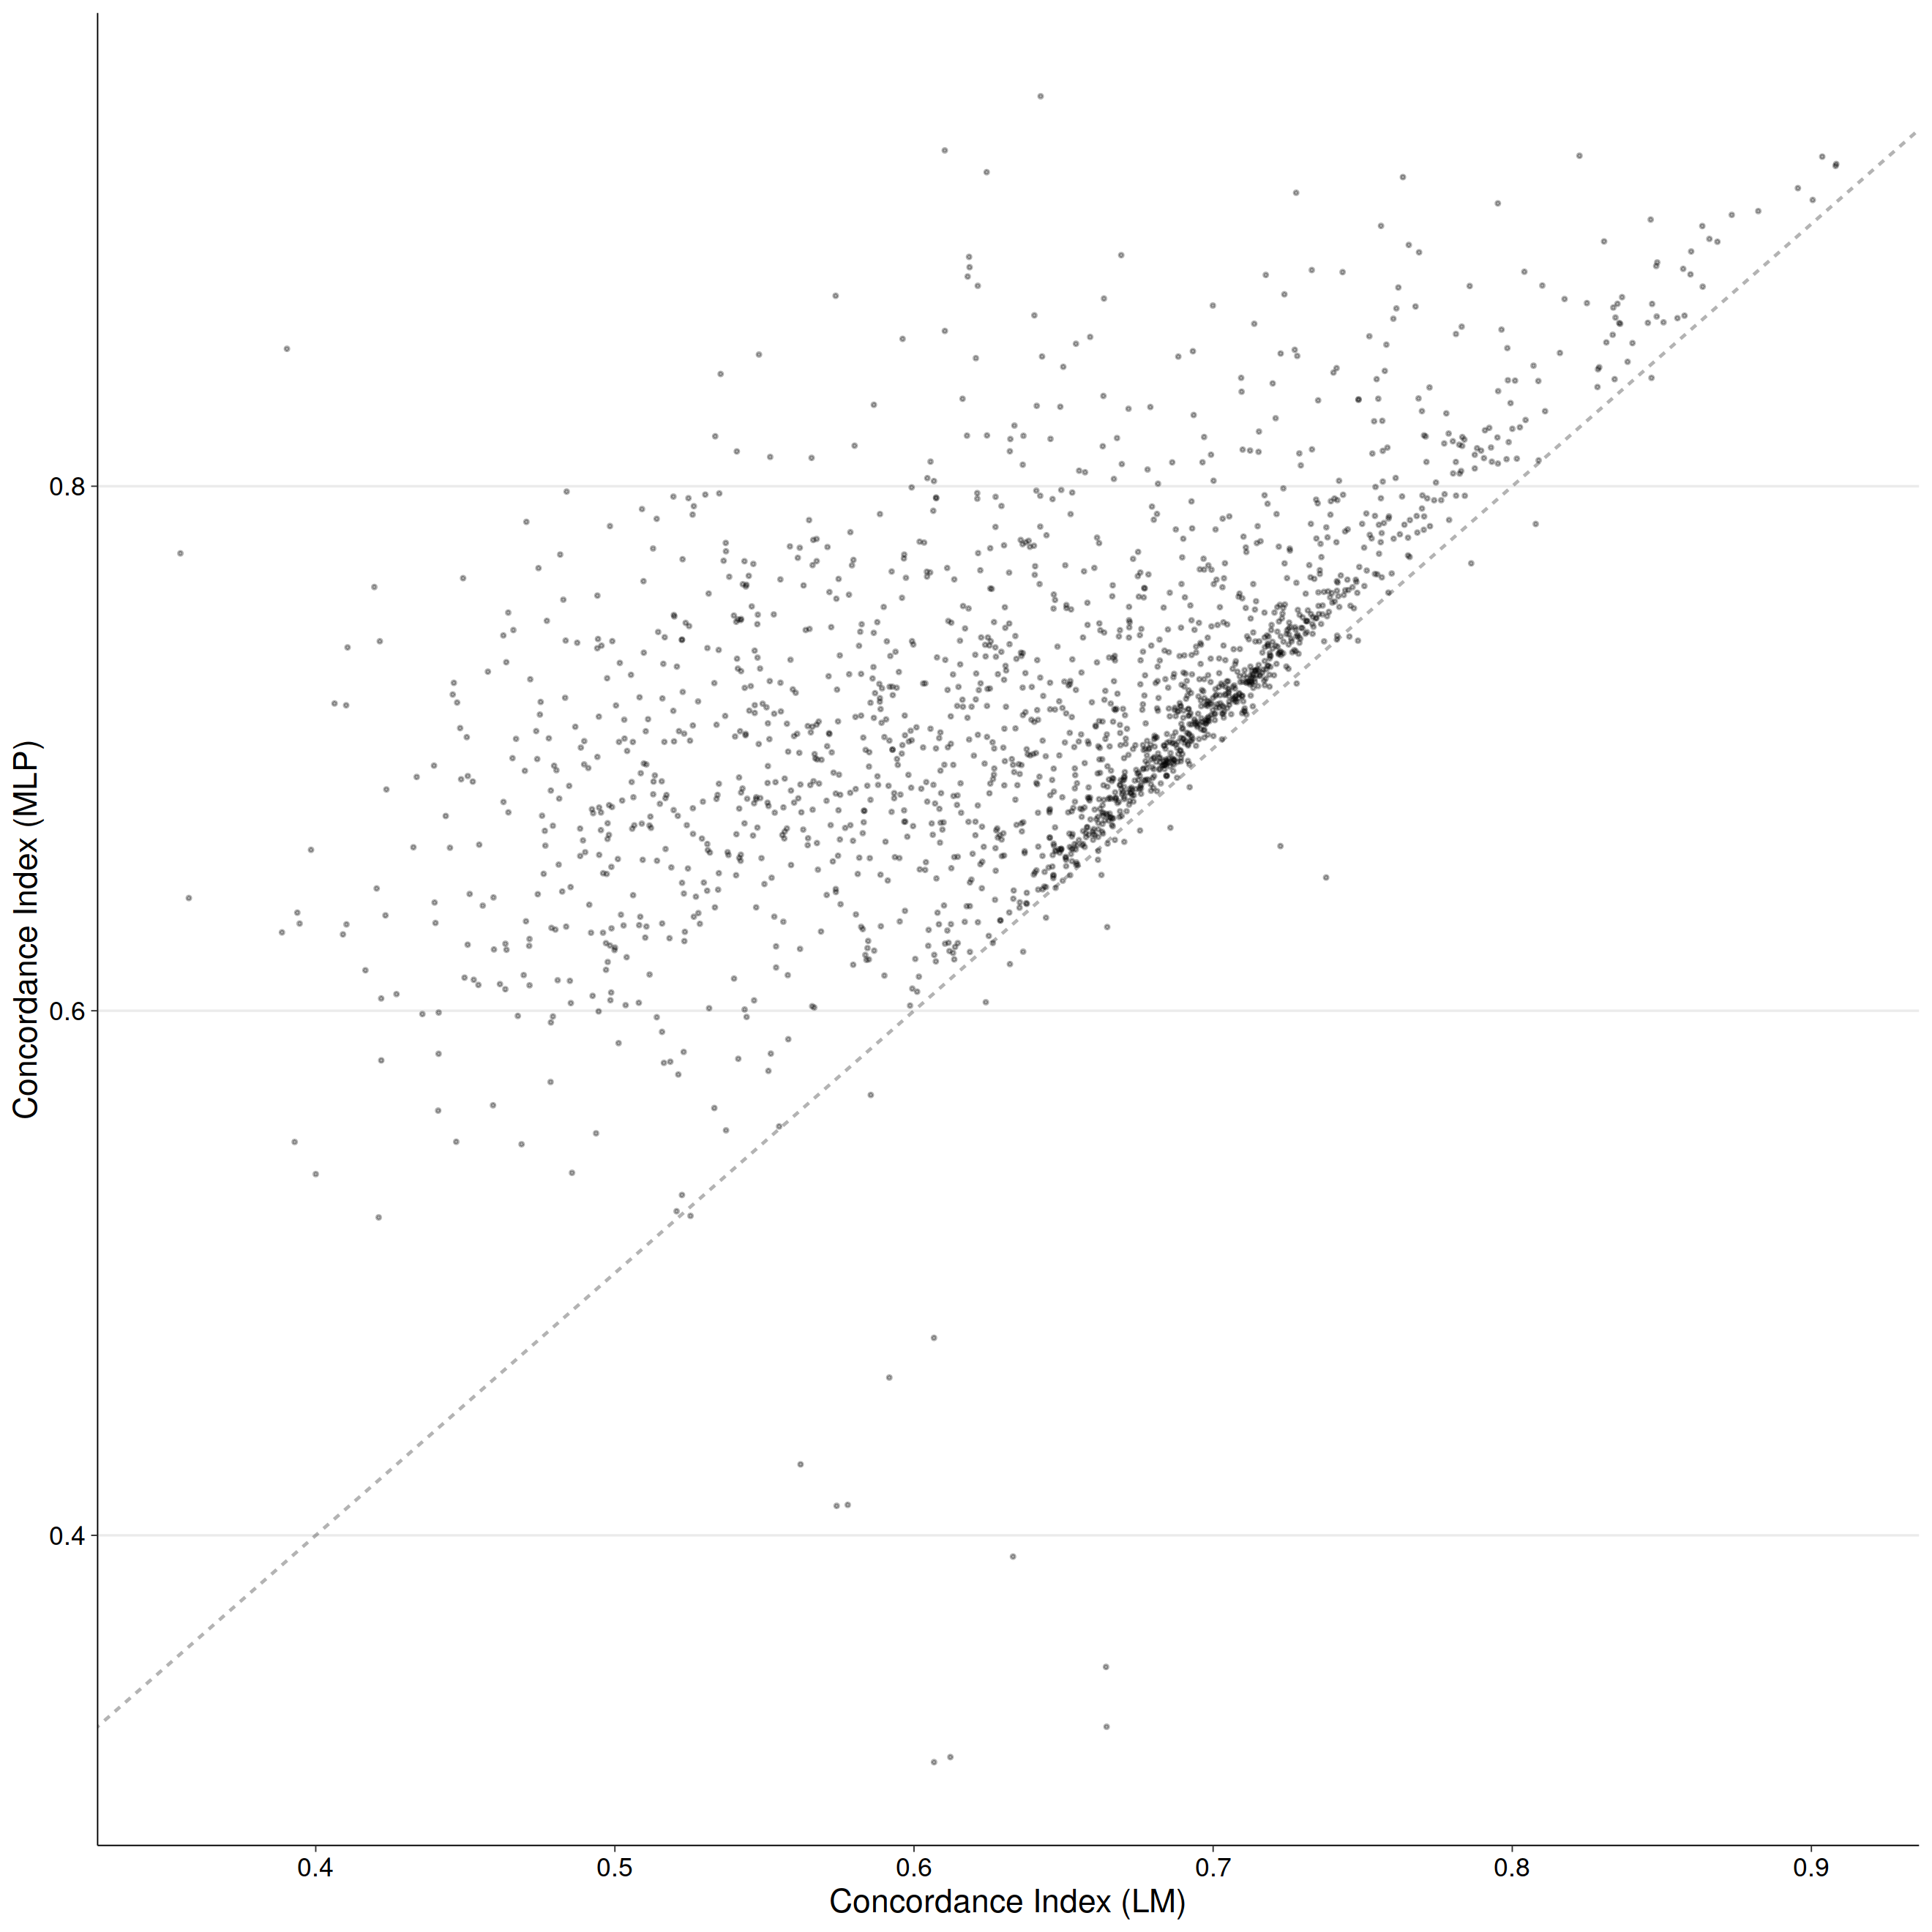

In [14]:
plot_width = 8.25; plot_height=8.25; plot_res = 320
options(repr.plot.width = plot_width, repr.plot.height = plot_height, repr.plot.res=plot_res)

suppl_lm = benchmarks_lm %>% 
    ggplot(aes(x=`MedicalHistoryLM`, y=`MedicalHistory`)) + 
    labs(x="Concordance Index (LM)", y="Concordance Index (MLP)")+
    geom_point(alpha=0.3, size=0.3)+
    geom_abline(alpha=0.3, linetype="22")

suppl_lm 

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



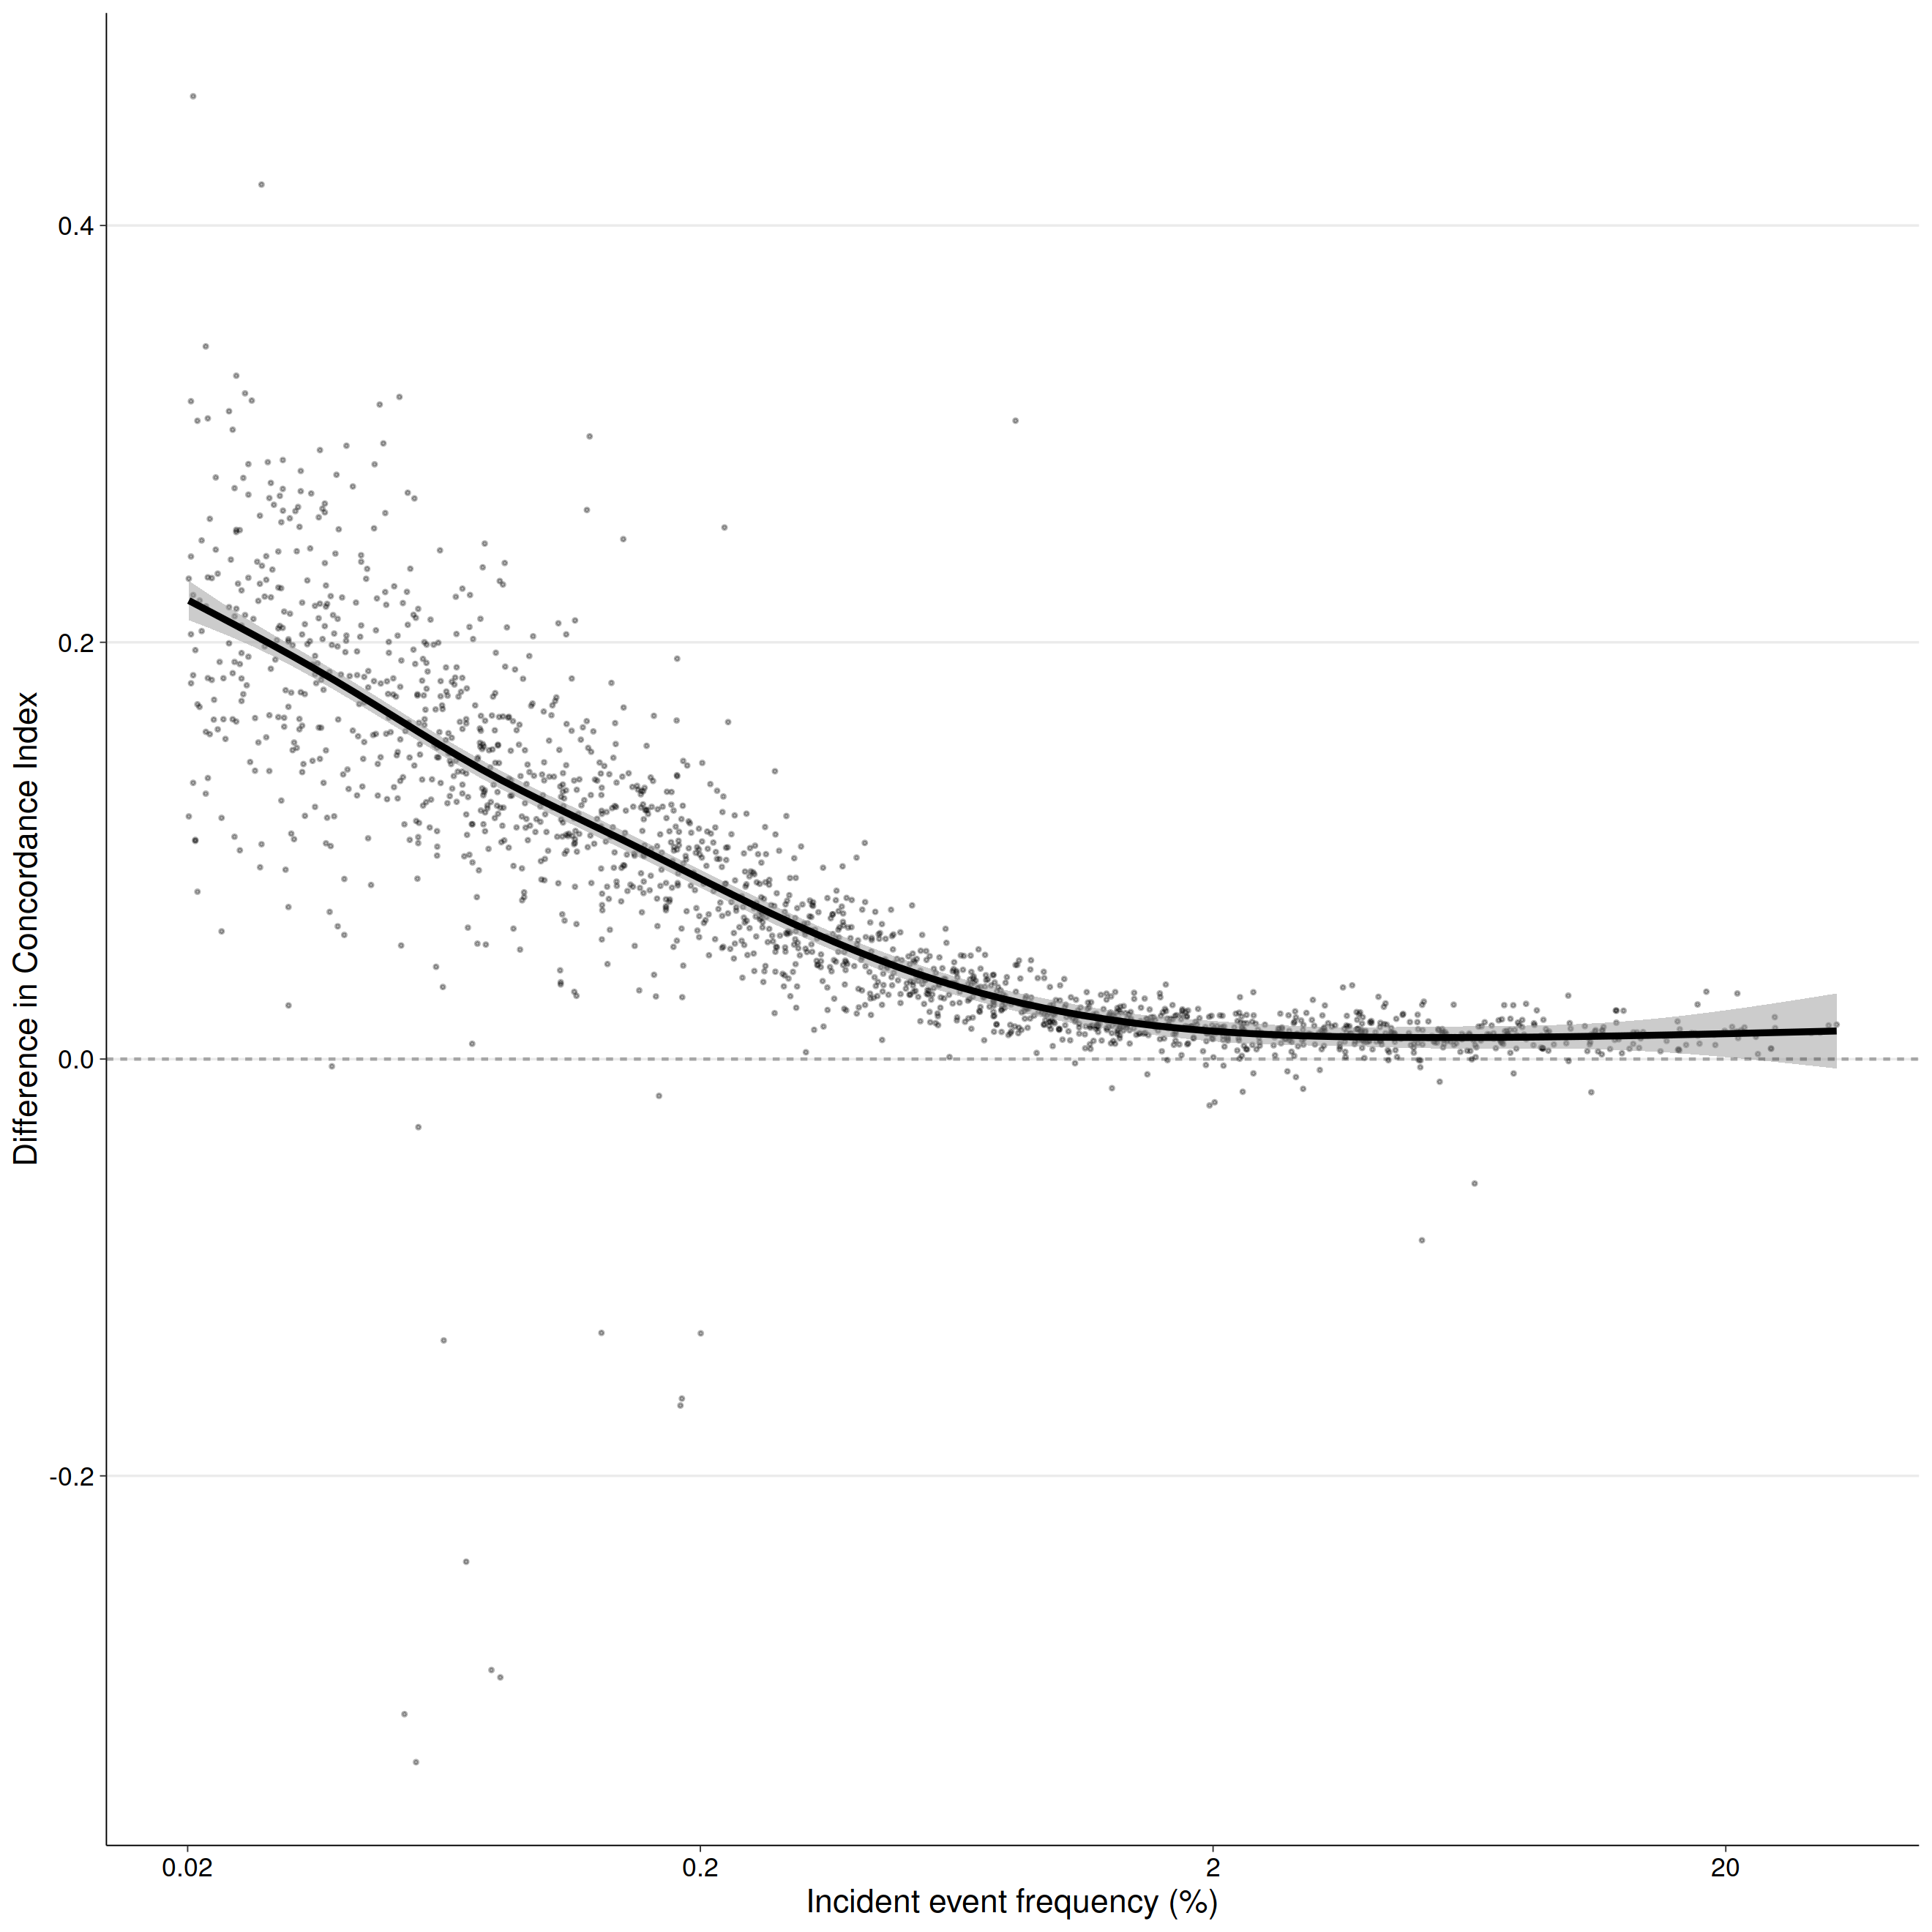

In [15]:
plot_width = 8.25; plot_height=8.25; plot_res = 320
options(repr.plot.width = plot_width, repr.plot.height = plot_height, repr.plot.res=plot_res)

suppl_delta = benchmarks_lm %>% 
    ggplot(aes(x=log(freq), y=delta)) + 
    labs(x="Incident event frequency (%)", y="Difference in Concordance Index")+
    geom_point(alpha=0.3, size=0.3)+
    geom_smooth(color="black", alpha=0.5)+
    #coord_cartesian(xlim=c(-Inf, NA))+
    scale_x_continuous(breaks=c(log(0.0002), log(0.002), log(0.02), log(0.2)), labels=c("0.02", "0.2", "2", "20"))+
    geom_hline(yintercept=0, alpha=0.3, linetype="22")

suppl_delta 

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



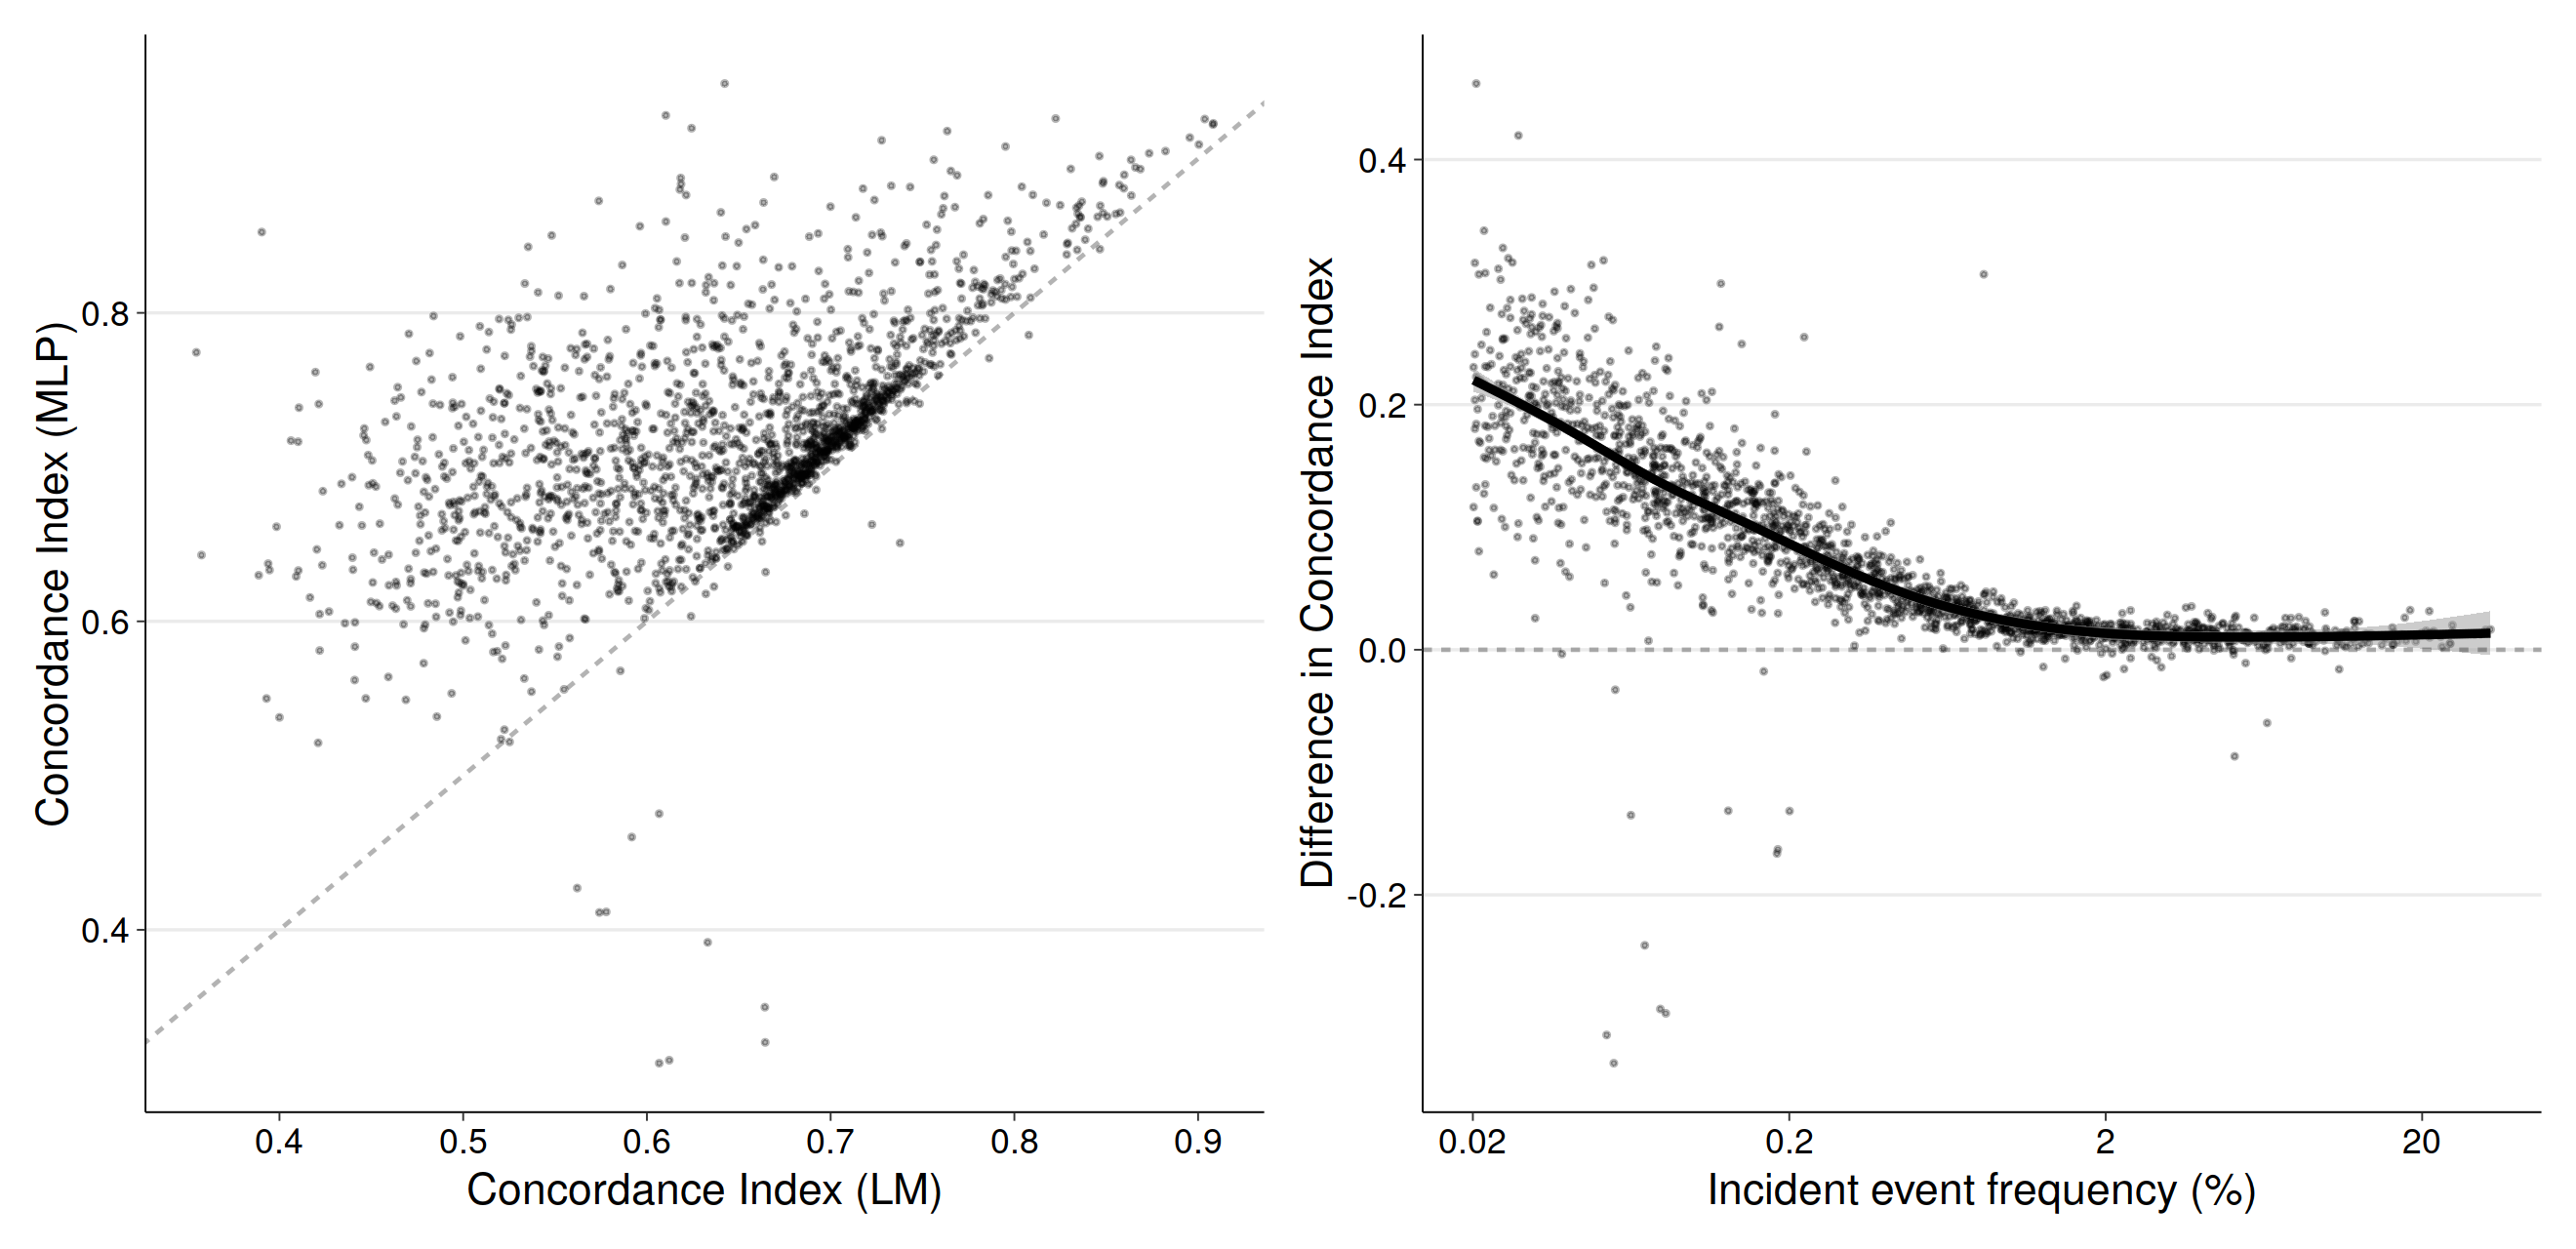

In [17]:
plot_width = 8.25; plot_height=4; plot_res = 320
options(repr.plot.width = plot_width, repr.plot.height = plot_height, repr.plot.res=plot_res)

lm_bc = suppl_lm | suppl_delta
lm_bc

In [18]:
plot_name = "SupplFigure2bc"
lm_bc %>% ggsave(filename=glue("outputs/{plot_name}.pdf"), device="pdf", width=plot_width, height=plot_height, dpi=plot_res)

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



benchmark_endpoints## General Performance

Warning message:
“package ‘ggtext’ was built under R version 4.0.5”
Warning message:
“package ‘ggdist’ was built under R version 4.0.5”


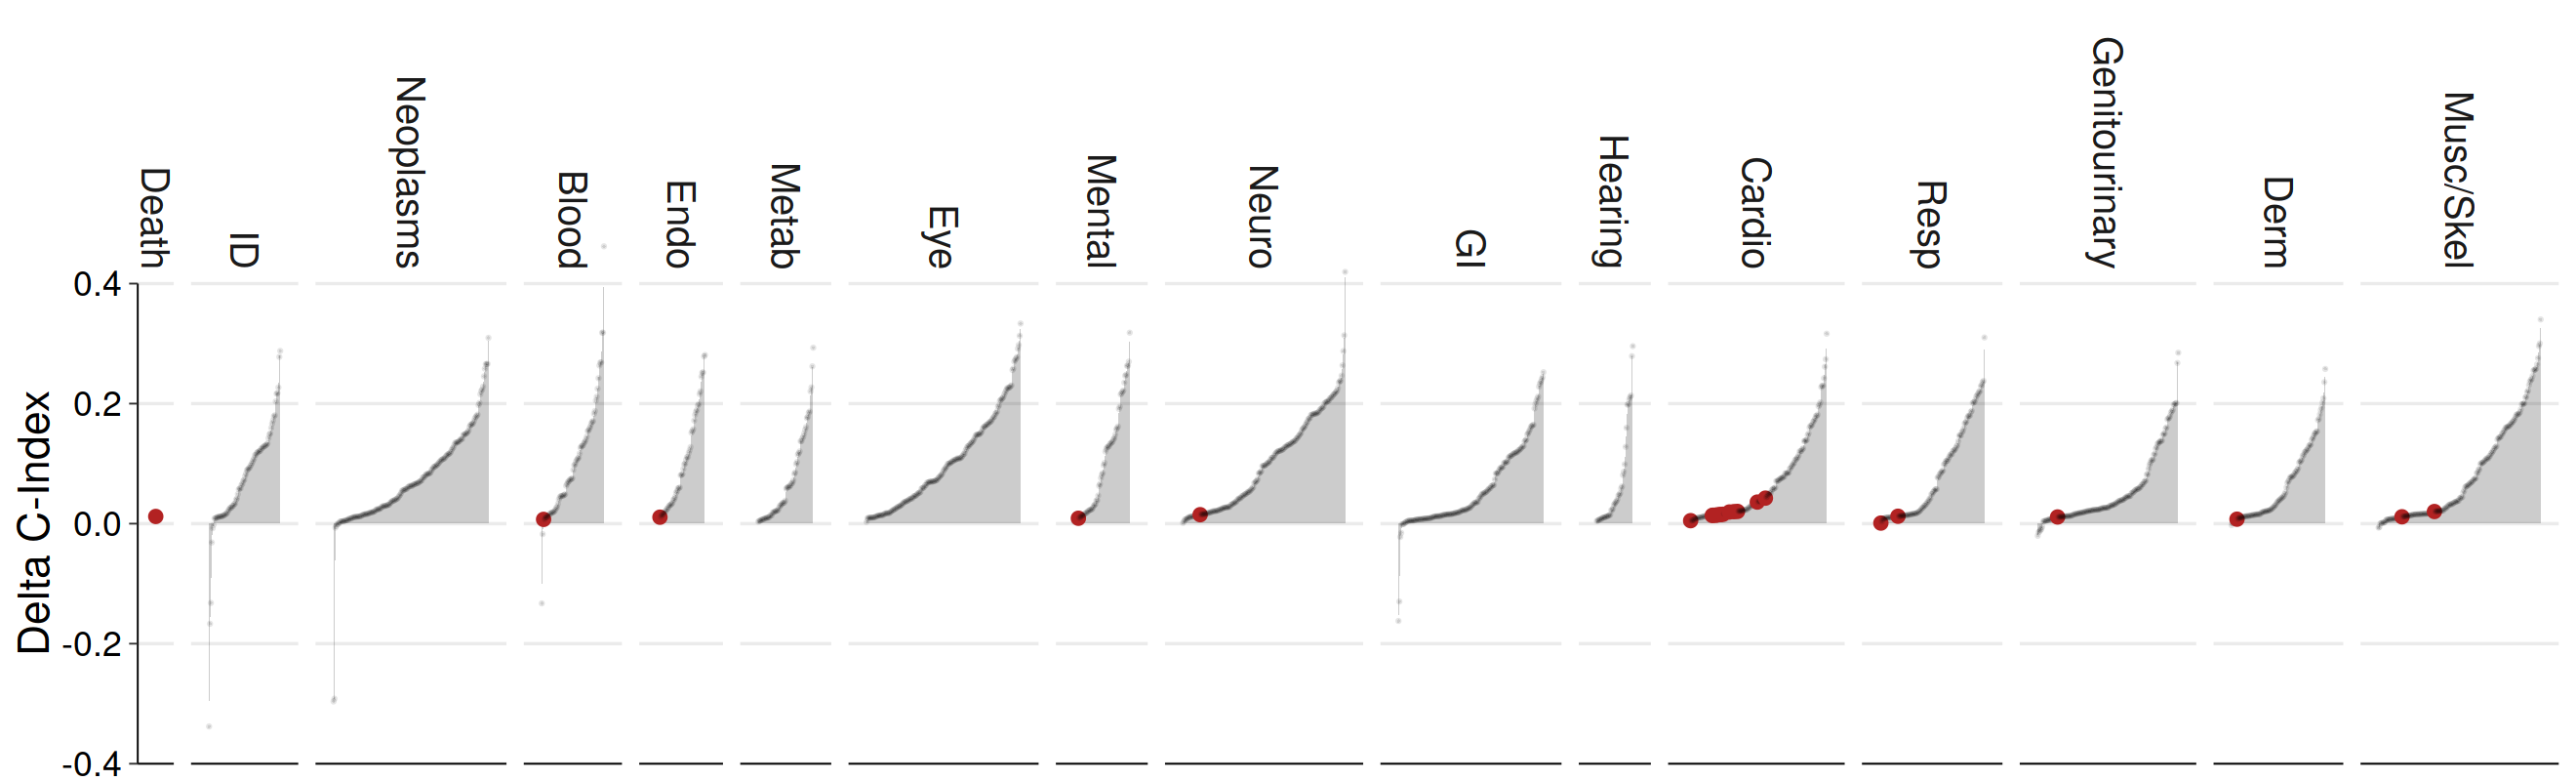

In [19]:
plot_width = 8.25; plot_height=2.5; plot_res = 320
options(repr.plot.width = plot_width, repr.plot.height = plot_height, repr.plot.res=plot_res)

library(ggtext)
library(ggdist)

scores_plot = c("MedicalHistoryLM", "MedicalHistory")#, "AgeSexMedicalHistory")

temp = benchmark_endpoints %>% 
    filter(score %in% scores_plot) %>% 
    mutate(score = factor(score, levels=scores_plot)) %>%
    mutate(endpoint = factor(endpoint, levels=endpoints_sorted)) %>%
    ungroup() %>%
    pivot_wider(names_from=score, values_from=cindex) %>% 
    mutate(id = row_number()) %>%
    mutate(delta = !!sym(scores_plot[2])-!!sym(scores_plot[1])) %>%
    group_by(endpoint, phecode_string, freq, phecode_category) %>%
    median_qi(delta) %>%
    mutate(pos = case_when(delta>=0 ~ "pos", delta < 0 ~"neg")) %>%
    mutate(endpoint = fct_reorder(endpoint, delta)) %>%
    mutate(highlight = case_when(endpoint %in% endpoint_selection ~ "YES", TRUE ~ "NO")) %>%# %>% filter(endpoint %in% endpoint_sample)
    mutate(phecode_category = factor(phecode_category, levels=categories_sorted))

endpoint_order = (temp %>% arrange(delta))$endpoint

temp = temp %>% mutate(endpoint = factor(endpoint, levels=endpoint_order)) %>% ungroup() %>% 
    arrange(endpoint) %>% group_by(phecode_category) %>% mutate(endpoint = row_number()) %>%
    filter(!phecode_category %in% c("Signs/Symptoms", "Preg", "Rx", "Stat"))

overview = ggplot(temp) +
    geom_ribbon(aes(x=endpoint, ymin=0, ymax=delta), fill="black", alpha=0.2)+
    geom_point(aes(x=endpoint, y=delta, color=highlight, size=highlight, alpha=highlight)) +
    #geom_text(data=temp %>% filter(highlight=="YES"), aes(x=endpoint, y=delta+0.045, label="↓"), color="black", size=5, alpha=0.7) +
    #geom_segment(aes(x=endpoint, xend=endpoint, y=0, yend=delta, color=highlight, size=highlight), alpha=0.5)+#+
    labs(x="Endpoints", y="Delta C-Index")+
    scale_color_manual(values=c("NO"="black", "YES"="firebrick"))+
    scale_alpha_manual(values=c("NO"=0.1, "YES"=1))+
    scale_size_manual(values=c("NO"=0.01, "YES"=1))+
    #scale_colour_manual(values = c("pos"="forestgreen", "neg" = "firebrick")) + 
    #coord_polar() +
    coord_cartesian(ylim=c(-0.4, 0.4), clip = "off")+
    scale_y_continuous(expand=c(0, 0))+
    scale_x_discrete(expand=expansion(add=20))+
    facet_grid(~phecode_category, scales="free_x", space="free_x")+#, switch=TRUE)+
    #facet_grid2(~phecode_category, scales = "free", independent = "all") + 
    theme(axis.title.x=element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank(),
        panel.grid.major=element_blank(), 
         strip.text = element_text(angle=270, hjust=1)) + 
    theme(legend.position="none") 
    
    #geom_ribbon(aes(x=id, ymin=AgeSex, ymax=`Age+Sex+MedicalHistory`), fill="red", alpha=0.2)
#geom_violin(size=0.1)
overview

In [21]:
library(gt)
plot_name = "SupplFigure2a_CompLM"
overview %>% ggsave(filename=glue("outputs/{plot_name}.pdf"), device="pdf", width=plot_width, height=plot_height, dpi=plot_res)

In [ ]:
temp %>% write_feather("outputs/cindexdeltas.feather")
temp %>% write_csv("outputs/cindexdeltas.csv")

In [ ]:
temp %>% ungroup() %>% group_by(.lower>0) %>% tally()

In [ ]:
1800/1883

In [ ]:
temp %>% ungroup() %>% filter(.lower>0) %>% median_qi(delta, .width = c(.25)) %>% select(.lower, delta, .upper)

In [ ]:
base_size = 8
title_size = 10
facet_size = 9
geom_text_size=3
theme_set(theme_classic(base_size = base_size) + 
          theme(strip.background = element_blank(), plot.title=element_text(size=title_size, hjust=0), 
                strip.text.x = element_text(size = facet_size),axis.title=element_text(size=10), axis.text=element_text(size=8, color="black"),
                legend.position="bottom", axis.line = element_line(size = 0.2), axis.ticks=element_line(size=0.2), panel.grid.major=element_line()))

## Performance against CVD Scores

In [ ]:
SCORE2: Myocardial infarction, Stroke, hypertensive heart disease, Ischemic heart disease, heart failure, arrhythmias, cardiovascular death + cardiac arrest
ASCVD: 
QRISK3:  Ischemic heart disease, Myocardial infarction, TIA, stroke

AF: some scores ESC


In [ ]:
endpoint_selection

In [25]:
plot_width = 8.25; plot_height=2; plot_res = 320
options(repr.plot.width = plot_width, repr.plot.height = plot_height, repr.plot.res=plot_res)

plot_against_score = function(score1, score2, endpoint_order=c()){
    
    scores_plot = c(score1, score2)#, "AgeSexMedicalHistory"
    
    score_label = glue("{score1} vs. {score2}")
    #print(score_label)

    temp = benchmark_endpoints %>% 
        filter(score %in% scores_plot) %>% 
        filter(endpoint %in% endpoint_selection) %>%
        mutate(score = factor(score, levels=scores_plot)) %>%
        mutate(endpoint = factor(endpoint, levels=sort(endpoint_selection))) %>%
        group_by(endpoint, score, phecode_string, phecode_category) %>%
        ungroup() %>%
        pivot_wider(names_from=score, values_from=cindex) %>% 
        mutate(id = row_number()) %>%
        mutate(delta = !!sym(score2)-!!sym(score1)) %>%
        mutate(pos = case_when(delta>=0 ~ "pos", delta < 0 ~"neg")) %>%
        mutate(endpoint = fct_reorder(endpoint, delta)) %>%
        mutate(highlight = case_when(endpoint %in% endpoint_selection ~ "YES", TRUE ~ "NO")) %>%# %>% filter(endpoint %in% endpoint_sample)
        mutate(phecode_category = factor(phecode_category, levels=categories_sorted)) %>%
        filter(endpoint %in% endpoint_selection) #%>% mutate(endpoint=factor(endpoint, levels=endpoint_order_diff))
    
    temp_abs = temp %>% group_by(endpoint) %>% summarise(delta=median(delta), m_score2=median(!!sym(score2)), m_score1=median(!!sym(score1))) %>% ungroup() 
    #print(levels(temp_abs$endpoint))
    
    temp_abs_segment = temp_abs %>% rowwise() %>% mutate(min_cindex = min(m_score1, m_score2), max_cindex=max(m_score1, m_score2)) %>% ungroup()# %>% filter(abs(min_cindex-max_cindex)>0.02) 
    
    endpoint_order = (temp %>% group_by(endpoint) %>% summarise(delta=median(delta)) %>% arrange(delta))$endpoint
    print(endpoint_order)
    
    if (length(endpoint_order)>0){
        temp = temp %>% filter(endpoint %in% endpoint_order) %>% mutate(endpoint=factor(endpoint, levels=endpoint_order))
        temp_abs = temp_abs %>% filter(endpoint %in% endpoint_order) %>% mutate(endpoint=factor(endpoint, levels=endpoint_order))
        temp_abs_segment = temp_abs_segment %>% filter(endpoint %in% endpoint_order) %>% mutate(endpoint=factor(endpoint, levels=endpoint_order))
        }
    #print(temp_abs_segment)
    
    abs = ggplot(temp_abs) + 
        #geom_violin(aes(x=fct_rev(endpoint), y=delta), size=0.5) +
        labs(y="Concordance Index")+

        #geom_segment(data=temp_abs_segment, mapping=aes(x=endpoint, xend=endpoint, y=min_cindex+0.01, yend=max_cindex-0.01), alpha=0.4)+#, arrow = arrow(length = unit(0.01, "npc")), arrow.fill="black")+#+

    
        geom_point(aes(x=fct_rev(endpoint), y=m_score1), size=1, color="black", alpha=0.7)+
        #geom_point(aes(x=fct_rev(endpoint), y=m_asm), size=1, color="#023768", alpha=0.7)+
        geom_point(aes(x=fct_rev(endpoint), y=m_score2), size=1.5, color="firebrick", alpha=0.7)+
        geom_segment(data=temp_abs %>% filter(abs(delta)>0.02) %>% mutate(endpoint=factor(endpoint, levels=endpoint_order)), 
                     aes(x=fct_rev(endpoint), xend=fct_rev(endpoint), y=m_score1+0.01, yend=m_score2-0.01), alpha=0.2, arrow = arrow(length = unit(0.01, "npc")), arrow.fill="black")+#,

        scale_x_discrete(labels=endpoint_map) +

        coord_flip(ylim=c(0.5, 0.9))+
         theme(strip.text = element_text(angle=270), axis.title.y=element_blank()) + 
        theme(legend.position="none")

        #geom_ribbon(aes(x=id, ymin=AgeSex, ymax=`Age+Sex+MedicalHistory`), fill="red", alpha=0.2)
    #geom_violin(size=0.1)
    rel = ggplot(temp) + 
        #geom_violin(aes(x=fct_rev(endpoint), y=delta), size=0.5) +
        labs(y="Difference in Concordance Index")+
        geom_hline(yintercept=0, size=0.25, alpha=0.5, linetype="22") + 
        stat_pointinterval(aes(x=fct_rev(endpoint), y=delta), size=0.5, alpha=0.7)+

        theme(axis.title.y=element_blank(),
            axis.text.y=element_blank(),
           axis.ticks.y=element_blank()) + 
        coord_flip(ylim=c(-0.01, 0.23))+
         theme(strip.text = element_text(angle=270)) + 
        theme(legend.position="none")

        #geom_ribbon(aes(x=id, ymin=AgeSex, ymax=`Age+Sex+MedicalHistory`), fill="red", alpha=0.2)
    #geom_violin(size=0.1) 
    return(abs|rel)
    }

In [20]:
library(ggdist)

In [21]:
base_size = 8
title_size = 10
facet_size = 9
geom_text_size=3
theme_set(theme_classic(base_size = base_size) + 
          theme(strip.background = element_blank(), plot.title=element_text(size=title_size, hjust=0), 
                strip.text.x = element_text(size = facet_size),axis.title=element_text(size=10), axis.text=element_text(size=8, color="black"),
                legend.position="bottom", axis.line = element_line(size = 0.2), axis.ticks=element_line(size=0.2), panel.grid.major=element_line()))

In [22]:
endpoint_order=c()
length(endpoint_order)

[1] 0

In [23]:
sort(endpoint_selection)

[1] "OMOP_4306655"   "phecode_164"    "phecode_202"    "phecode_284"   
 [5] "phecode_324-11" "phecode_400"    "phecode_401"    "phecode_404"   
 [9] "phecode_404-1"  "phecode_410-2"  "phecode_413-11" "phecode_413-21"
[13] "phecode_416-21" "phecode_420"    "phecode_424"    "phecode_431-11"
[17] "phecode_438-11" "phecode_440-3"  "phecode_468"    "phecode_474"   
[21] "phecode_583"    "phecode_665"    "phecode_705-1"  "phecode_718"

 [1] phecode_401    phecode_474    phecode_431-11 phecode_404-1  phecode_404   
 [6] phecode_468    phecode_413-21 phecode_424    phecode_324-11 phecode_400   
[11] phecode_164    phecode_583    phecode_438-11 phecode_440-3  OMOP_4306655  
[16] phecode_413-11 phecode_665    phecode_705-1  phecode_416-21 phecode_202   
[21] phecode_284    phecode_718    phecode_420    phecode_410-2 
24 Levels: phecode_401 phecode_474 phecode_431-11 phecode_404-1 ... phecode_410-2


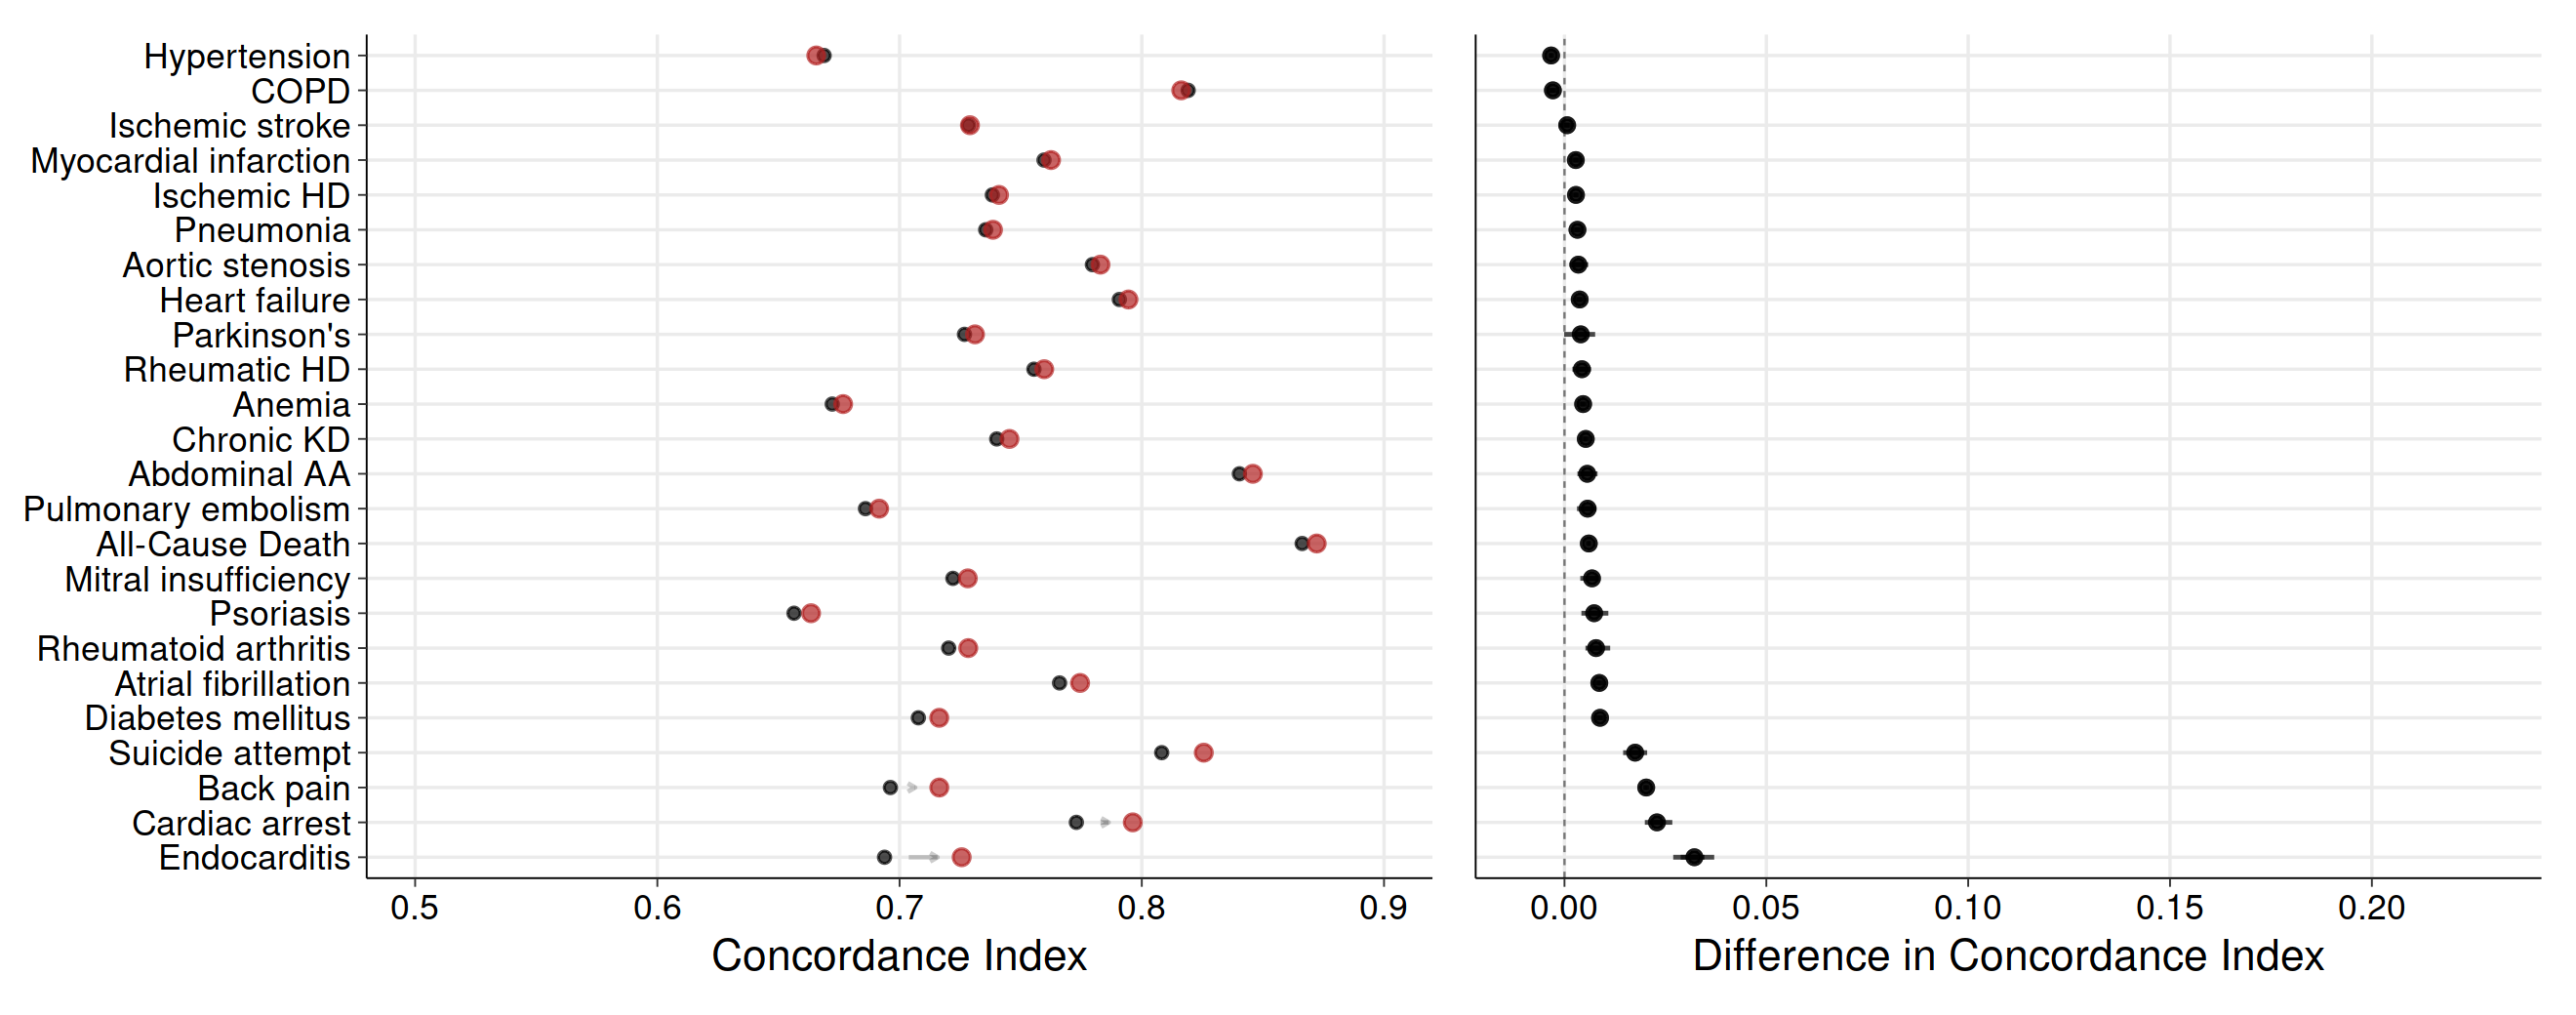

In [24]:
plot_width = 8.25; plot_height=3.25; plot_res = 320
options(repr.plot.width = plot_width, repr.plot.height = plot_height, repr.plot.res=plot_res)

fig3b = plot_against_score("Age+Sex+MedicalHistoryLM", "Age+Sex+MedicalHistory")
fig3b

In [132]:
library(gt)
plot_name = "SupplFig2_CompLM_selection"
fig3b %>% ggsave(filename=glue("outputs/{plot_name}.pdf"), device=cairo_pdf, width=plot_width, height=plot_height, dpi=plot_res)

In [ ]:
library(ggdist)

In [ ]:
table_2 = benchmark_endpoints %>% 
    filter(score %in% scores_plot) %>% 
    mutate(score = factor(score, levels=scores_plot)) %>%
    mutate(endpoint = factor(endpoint, levels=endpoints_sorted)) %>%
    group_by(endpoint, score, phecode_string, phecode_category) %>%
    pivot_wider(names_from=score, values_from=cindex) %>% 
    mutate(id = row_number()) %>%
    mutate(delta = `MedicalHistory`-`MedicalHistoryLM`) %>%
    #select(endpoint, iteration, phecode_string, phecode_category, sex, `Age+Sex`, `Age+Sex+MedicalHistory`, delta) %>%
    pivot_longer(all_of(c("MedicalHistoryLM", "MedicalHistory", "delta")), names_to="type", values_to="cindex") %>%
    group_by(endpoint, phecode_string, phecode_category, type) %>%
    median_qi(cindex, .width=1-(0.05/1883)) %>%
    mutate(agg = glue("{round(cindex, 3)} ({round(.lower, 3)}, {round(.upper, 3)})")) %>%
    ungroup() %>% select(endpoint, phecode_string, phecode_category, type, agg) %>%
    pivot_wider(names_from=type, values_from=agg) %>%
      mutate(delta2 = str_replace_all(delta, "\\(", ",")) %>% mutate(delta2 = str_replace_all(delta2, "\\)", "")) %>% #mutate(delta2 = str_replace_all(delta2, ",", " ")) %>%#mutate(delta2 = gsub(")", "", delta2)) %>%
    separate(delta2, into = c("delta_median", "delta_lower", "delta_upper"), sep = ",", remove = TRUE, extra = "merge") %>%
      mutate(delta_median= as.numeric(delta_median),
             delta_lower = as.numeric(delta_lower),
             delta_upper = as.numeric(delta_upper)) %>%
    mutate(sign = case_when(
        delta_upper<0 ~ "-",
        delta_lower>0 ~ "+",
        TRUE ~ "ns")) %>%
    select(-delta_upper, -delta_lower) %>% arrange(as.character(endpoint)) %>% 
    rename(delta_lm=delta, sign_lm=sign, delta_median_lm = delta_median)

table_2

In [ ]:
table_2 %>% group_by(sign_lm) %>% tally() %>% mutate(freq=n/sum(n))

In [ ]:
table_2 %>% 
    select(all_of(c("endpoint", "phecode_string", "Age+Sex", 'Age+Sex+MedicalHistory', "delta"))) %>%
    mutate(endpoint = factor(endpoint, levels = endpoints_md$endpoint)) %>% 
    filter(endpoint %in% endpoint_selection) %>%
    arrange(endpoint)

In [ ]:
options(pillar.print_max = Inf)
table_2 %>% 
    select(all_of(c("phecode_category", "endpoint", "phecode_string", "Age+Sex", 'Age+Sex+MedicalHistory', "delta"))) %>%
    mutate(endpoint = factor(endpoint, levels = endpoints_md$endpoint)) %>% 
    #filter(endpoint %in% endpoint_selection) %>%
    arrange(endpoint) %>% 
    write_csv("outputs/SupplTable5_DiscriminativePerformanceAll.csv")

In [ ]:
table_2 %>% filter(endpoint %in% endpoint_selection) %>% arrange(as.character(endpoint)) %>% arrange(delta)